In [ ]:
import os
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
import shutil 
import xml.etree.ElementTree as ET
import pydicom


In [ ]:
# json copy
import os
import shutil
import json

def copy_json_files(src_dir, dst_dir):
    json_paths = []  
    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.endswith('.json'):
                src_file_path = os.path.join(root, file)
                dst_file_path = os.path.join(dst_dir, file)
                shutil.copy(src_file_path, dst_dir)
                print(f"Copied: {src_file_path} to {dst_dir}")
                json_paths.append(os.path.abspath(dst_file_path))
    
    return json_paths

src_directory = r"D:\MED\SpM\SpM MRI-jpg"
dst_directory = r"D:\MED\SpM\SpM Compression"

os.makedirs(dst_directory, exist_ok=True)

json_paths = copy_json_files(src_directory, dst_directory)

print(json.dumps(json_paths, indent=4))


Copied: D:\MED\SpM\SpM MRI-jpg\20230227003509-0000678823-CHU GUO WAN\1.3.46.670589.11.78361.5.0.19352.2023022711194812004.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230227003509-0000678823-CHU GUO WAN\1.3.46.670589.11.78361.5.0.19352.2023022711194813006.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230227003509-0000678823-CHU GUO WAN\1.3.46.670589.11.78361.5.0.19352.2023022711194815008.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230227003509-0000678823-CHU GUO WAN\1.3.46.670589.11.78361.5.0.19352.2023022711194816010.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230227003509-0000678823-CHU GUO WAN\1.3.46.670589.11.78361.5.0.19352.2023022711194817012.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230227003509-0000678823-CHU GUO WAN\1.3.46.670589.11.78361.5.0.19352.2023022711194818014.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230227003509-0000678823-C

Copied: D:\MED\SpM\SpM MRI-jpg\20230302006611-0000680056-DONG XIAO LING\1.3.46.670589.11.78360.5.0.6552.2023030222183853177.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230302006611-0000680056-DONG XIAO LING\1.3.46.670589.11.78360.5.0.6552.2023030222183853178.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230302006611-0000680056-DONG XIAO LING\1.3.46.670589.11.78360.5.0.6552.2023030222183854179.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230302006611-0000680056-DONG XIAO LING\1.3.46.670589.11.78360.5.0.6552.2023030222183854180.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230302006611-0000680056-DONG XIAO LING\1.3.46.670589.11.78360.5.0.6552.2023030222183855181.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230302006611-0000680056-DONG XIAO LING\1.3.46.670589.11.78360.5.0.6552.2023030222183855182.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230302006611-

Copied: D:\MED\SpM\SpM MRI-jpg\20230322004416-0000683584-LI JUN\1.2.156.112605.189250946103397.20230322120905.4.6600.7.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230322004416-0000683584-LI JUN\1.2.156.112605.189250946103397.20230322120906.4.6600.1.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230322004416-0000683584-LI JUN\1.2.156.112605.189250946103397.20230322120906.4.6600.102.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230322004416-0000683584-LI JUN\1.2.156.112605.189250946103397.20230322120906.4.6600.6.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230322004416-0000683584-LI JUN\1.2.156.112605.189250946103397.20230322120906.4.6600.82.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230322004416-0000683584-LI JUN\1.2.156.112605.189250946103397.20230322120906.4.6600.86.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230322004416-0000683584-LI JUN\1.2.156.

Copied: D:\MED\SpM\SpM MRI-jpg\20230418004580-0000687937-XUE CHUI PING\1.2.156.112605.189250946103397.20230420000313.4.18156.17.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230418004580-0000687937-XUE CHUI PING\1.2.156.112605.189250946103397.20230420000313.4.18156.18.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230418004580-0000687937-XUE CHUI PING\1.2.156.112605.189250946103397.20230420000313.4.18156.3.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230418004580-0000687937-XUE CHUI PING\1.2.156.112605.189250946103397.20230420000313.4.18156.5.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230418004580-0000687937-XUE CHUI PING\1.2.156.112605.189250946103397.20230420000313.4.18156.9.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230418004580-0000687937-XUE CHUI PING\1.2.156.112605.189250946103397.20230420000314.4.18156.1.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI

Copied: D:\MED\SpM\SpM MRI-jpg\20230425000921-0000689232-ZHANG SU FANG\1.3.46.670589.11.78361.5.0.6604.2023042614542021657.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230425000921-0000689232-ZHANG SU FANG\1.3.46.670589.11.78361.5.0.6604.2023042614542021658.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230425000921-0000689232-ZHANG SU FANG\1.3.46.670589.11.78361.5.0.6604.2023042614542022659.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230425000921-0000689232-ZHANG SU FANG\1.3.46.670589.11.78361.5.0.6604.2023042614542022660.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230425000921-0000689232-ZHANG SU FANG\1.3.46.670589.11.78361.5.0.6604.2023042614542022661.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230425000921-0000689232-ZHANG SU FANG\1.3.46.670589.11.78361.5.0.6604.2023042614542024662.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230425000921-000068

...

Copied: D:\MED\SpM\SpM MRI-jpg\20230913004532-0000709623-SHAO YU HONG\1.3.12.2.1107.5.2.19.45462.2023091407241345614387319.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230913004532-0000709623-SHAO YU HONG\1.3.12.2.1107.5.2.19.45462.2023091407241348585687324.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230913004532-0000709623-SHAO YU HONG\1.3.12.2.1107.5.2.19.45462.2023091407241350800087330.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230913004532-0000709623-SHAO YU HONG\1.3.12.2.1107.5.2.19.45462.2023091407241351353487334.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230913004532-0000709623-SHAO YU HONG\1.3.12.2.1107.5.2.19.45462.2023091407241356484187346.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230913004532-0000709623-SHAO YU HONG\1.3.12.2.1107.5.2.19.45462.2023091407241356776587349.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230913004532-000070

Copied: D:\MED\SpM\SpM MRI-jpg\20230927002324-0000484786-SHI YI WEI\1.2.156.112605.189250946103397.20230927135040.4.21112.10.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230927002324-0000484786-SHI YI WEI\1.2.156.112605.189250946103397.20230927135040.4.21112.15.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230927002324-0000484786-SHI YI WEI\1.2.156.112605.189250946103397.20230927135040.4.21112.17.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230927002324-0000484786-SHI YI WEI\1.2.156.112605.189250946103397.20230927135040.4.21112.19.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230927002324-0000484786-SHI YI WEI\1.2.156.112605.189250946103397.20230927135040.4.21112.21.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20230927002324-0000484786-SHI YI WEI\1.2.156.112605.189250946103397.20230927135040.4.21112.23.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\202309270

Copied: D:\MED\SpM\SpM MRI-jpg\20231015000565-0000713384-LIANG ZONG BAO\1.3.12.2.1107.5.2.19.45462.2023101518485782488746457.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231015000565-0000713384-LIANG ZONG BAO\1.3.12.2.1107.5.2.19.45462.2023101518485783517146458.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231019000762-0000713764-YAN JIN XI\1.3.12.2.1107.5.2.19.45462.2023101922541946368110506.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231019000762-0000713764-YAN JIN XI\1.3.12.2.1107.5.2.19.45462.2023101922541948175310511.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231019000762-0000713764-YAN JIN XI\1.3.12.2.1107.5.2.19.45462.2023101922541950114310516.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231019000762-0000713764-YAN JIN XI\1.3.12.2.1107.5.2.19.45462.2023101922541951816310519.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231019000762-0000713764

Copied: D:\MED\SpM\SpM MRI-jpg\20231106000034-0000393325-MA BAO SHUAN\1.3.46.670589.11.78361.5.0.15392.2023110621555013006.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231106000034-0000393325-MA BAO SHUAN\1.3.46.670589.11.78361.5.0.15392.2023110621555014008.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231106000034-0000393325-MA BAO SHUAN\1.3.46.670589.11.78361.5.0.15392.2023110621555015010.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231106000034-0000393325-MA BAO SHUAN\1.3.46.670589.11.78361.5.0.15392.2023110621555016012.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231106000034-0000393325-MA BAO SHUAN\1.3.46.670589.11.78361.5.0.15392.2023110621555018014.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231106000034-0000393325-MA BAO SHUAN\1.3.46.670589.11.78361.5.0.15392.2023110621555019016.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231106000034-000039

Copied: D:\MED\SpM\SpM MRI-jpg\20231204001864-0000720190-SUN PIN XIU\1.2.840.113619.2.495.10795885.11627982.25290.1700861912.668.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231204001864-0000720190-SUN PIN XIU\1.2.840.113619.2.495.10795885.11627982.25290.1700861912.669.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231204001864-0000720190-SUN PIN XIU\1.2.840.113619.2.495.10795885.11627982.25290.1700861912.670.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231204001864-0000720190-SUN PIN XIU\1.2.840.113619.2.495.10795885.11627982.25290.1700861912.671.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231209000565-0000720843-TIAN CAI XIA\1.3.46.670589.11.78361.5.0.8196.2023121016315840622.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg\20231209000565-0000720843-TIAN CAI XIA\1.3.46.670589.11.78361.5.0.8196.2023121016315845624.json to D:\MED\SpM\SpM Compression
Copied: D:\MED\SpM\SpM MRI-jpg

In [ ]:
# json and dicom route distraction
import os
import json

json_dir = r"D:\MED\SpM\SpM Compression"
dcm_dir = r"D:\MED\SpM\SpM MRI-dcm"

json_filenames = [os.path.splitext(file)[0] for file in os.listdir(json_dir) if file.endswith('.json')]

dcm_paths = []

for root, dirs, files in os.walk(dcm_dir):
    for file in files:
        if file.endswith('.dcm'):
            dcm_filename = os.path.splitext(file)[0]
            if dcm_filename in json_filenames:
                dcm_path = os.path.join(root, file)
                dcm_paths.append(os.path.abspath(dcm_path))

print(json.dumps(dcm_paths, indent=4))

[
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678823\\1.3.46.670589.11.78361.5.0.19352.2023022711194812004.dcm",
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678823\\1.3.46.670589.11.78361.5.0.19352.2023022711194813006.dcm",
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678823\\1.3.46.670589.11.78361.5.0.19352.2023022711194815008.dcm",
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678823\\1.3.46.670589.11.78361.5.0.19352.2023022711194816010.dcm",
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678823\\1.3.46.670589.11.78361.5.0.19352.2023022711194817012.dcm",
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678823\\1.3.46.670589.11.78361.5.0.19352.2023022711194818014.dcm",
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678823\\1.3.46.670589.11.78361.5.0.19352.2023022711194819016.dcm",
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678823\\1.3.46.670589.11.78361.5.0.19352.2023022711194820018.dcm",
    "D:\\MED\\SpM\\SpM MRI-dcm\\20230227003509-0000678

In [ ]:
# label value check
import json
import os

valid_labels = {'1', '2', '3', '4', '5', '6'}

dst_directory = r"D:\MED\SpM\SpM Compression"

abnormal_json_files = []

for root, _, files in os.walk(dst_directory):
    for file in files:
        if file.endswith('.json'):
            json_path = os.path.join(root, file)
            with open(json_path, 'r') as json_file:
                try:
                    data = json.load(json_file)
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON file {json_path}: {e}")
                    continue

                shapes = data.get('shapes', [])
                
                if not isinstance(shapes, list):
                    continue  

                for shape in shapes:
                    if isinstance(shape, dict):
                        label = shape.get('label', None)
                        if label is not None and label not in valid_labels:
                            abnormal_json_files.append(json_path)
                            break  

if abnormal_json_files:
    print("包含异常值的JSON文件:")
    for abnormal_file in abnormal_json_files:
        print(abnormal_file)
else:
    print("所有JSON文件的label均在合法范围内")

所有JSON文件的label均在合法范围内


In [ ]:
# label value modification
import os
import json

dst_directory = r"D:\MED\SpM\SpM Compression"

label_mapping = {
    '1': '0',
    '2': '0',
    '3': '0',
    '4': '1',
    '5': '1',
    '6': '1'
}

for root, _, files in os.walk(dst_directory):
    for file in files:
        if file.endswith('.json'):
            json_path = os.path.join(root, file)
            with open(json_path, 'r', encoding='utf-8') as json_file:
                try:
                    data = json.load(json_file)
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON file {json_path}: {e}")
                    continue

            for shape in data.get('shapes', []):
                label = shape.get('label')
                if label in label_mapping:
                    shape['label'] = label_mapping[label]

            with open(json_path, 'w', encoding='utf-8') as json_file:
                json.dump(data, json_file, indent=4)

            print(f"Updated: {json_path}")

print("所有JSON文件的label已修改")

Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120856.4.6600.1.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120857.4.6600.1.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120857.4.6600.10.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120857.4.6600.12.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120857.4.6600.14.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120857.4.6600.15.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120857.4.6600.16.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120857.4.6600.17.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120857.4.6600.5.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120858.4.6600.1.json
Updated: D:\MED\SpM\SpM Compressio

Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231817.4.13404.2.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231817.4.13404.21.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231817.4.13404.29.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231817.4.13404.5.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231817.4.13404.56.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231817.4.13404.59.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231817.4.13404.8.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231818.4.13404.1.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231818.4.13404.3.json
Updated: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231818.4.13404.5.json
Updated: D:\MED\SpM\SpM Co

Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24429.1687735508.600.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24429.1687735508.601.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24429.1687735508.602.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24429.1687735508.603.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24520.1678084568.560.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24520.1678084568.561.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24520.1678084568.562.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24520.1678084568.563.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24520.1678084568.564.json
Updated: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24520.1678084568

Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061613345833858946206.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061613345834848746208.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061613345837744346212.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061613345839797846216.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061613345840765646217.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061613345842480346218.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061616490393664112291.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061616490395375812295.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061616490396735512300.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023061616490398112512305.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.454

Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023072622593393148694299.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023072622593432612094312.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023072622593434330094313.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023072622593435032194314.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023072622593436148394315.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023080113391079194561561.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023080113391081168561563.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023080113391083178661568.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023080113391085617661576.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023080113391090066761579.json
Updated: D:\MED\SpM\SpM Compression\1.3.12.2.1107.

...

Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524144008.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524145010.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524147012.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524148014.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524150016.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524151018.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524153020.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524154022.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524155024.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.2023052607524156026.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.4880.20

Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295055037.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295056039.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295057041.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295058043.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295059045.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295060047.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295061049.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295062051.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295063053.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.2023102814295064055.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.8444.20

Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372468006.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372469008.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372471010.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372471012.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372472014.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372474016.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372475018.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372475020.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372477022.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.19684.2023091320372479024.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5

Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052810184679204.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052810184680205.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052810184680206.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052810184681207.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052810184681208.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052810184681209.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052810184683210.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052810184683211.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052815201115950.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.2023052815201116951.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.6564.20

Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.8312.2023121221335038028.json
Updated: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.8312.2023121221335039030.json
所有JSON文件的label已修改


In [6]:
print(len(dcm_paths))
print(len(json_paths))

2458
2458


In [ ]:
# data augmentation, image and bboxes transformation
import pydicom
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import json
import torchvision.transforms as transforms
import random
import torchvision.transforms.functional as F

# 定义类别映射
class_to_id = {'A': 1}

# 修改为从 JSON 文件中获取标签和边界框
def get_labelFromJson(json_file):
    bbox_list = []
    labels = []
    print(f"Opening file: {json_file}")
    try:
        with open(json_file, 'r', encoding='utf-8') as an_file:
            data = json.load(an_file)
            for shape in data['shapes']:
                label = int(shape['label'])  # 假设label为整数
                points = shape['points']
                xmin = points[0][0]
                ymin = points[0][1]
                xmax = points[1][0]
                ymax = points[1][1]

                if xmin == 0 or xmax == 0 or ymin == 0 or ymax == 0:
                    continue
                elif xmin >= xmax or ymin >= ymax:
                    continue
                else:
                    bbox = [xmin, ymin, xmax, ymax]
                    bbox_list.append(bbox)
                    labels.append(label)
    except Exception as e:
        print(f"Error parsing file {json_file}: {e}")

    return bbox_list, labels

class CustomCompose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, target):
        if random.random() < self.p:
            image = F.hflip(image)
            width = image.width
            boxes = target['boxes']
            boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
            target['boxes'] = boxes
        return image, target

class RandomVerticalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, target):
        if random.random() < self.p:
            image = F.vflip(image)
            height = image.height
            boxes = target['boxes']
            boxes[:, [1, 3]] = height - boxes[:, [3, 1]]
            target['boxes'] = boxes
        return image, target

class RandomCropResize:
    def __init__(self, size, scale=(0.8, 1.0)):
        self.size = size
        self.scale = scale

    def __call__(self, image, target):
        i, j, h, w = transforms.RandomResizedCrop.get_params(image, scale=self.scale, ratio=(1.0, 1.0))
        image = F.resized_crop(image, i, j, h, w, self.size)

        boxes = target['boxes']
        scale_x = self.size[0] / w
        scale_y = self.size[1] / h

        boxes[:, [0, 2]] = (boxes[:, [0, 2]] - j) * scale_x
        boxes[:, [1, 3]] = (boxes[:, [1, 3]] - i) * scale_y
        target['boxes'] = boxes

        return image, target

class ColorJitter:
    def __init__(self, brightness=0, contrast=0):
        self.transform = transforms.ColorJitter(brightness=brightness, contrast=contrast)

    def __call__(self, image, target):
        image = self.transform(image)
        return image, target

class GaussianBlur:
    def __init__(self, kernel_size, sigma):
        self.transform = transforms.GaussianBlur(kernel_size, sigma)

    def __call__(self, image, target):
        image = self.transform(image)
        return image, target

class ToTensor:
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target

# 图像变换
base_transformer = CustomCompose([
    ToTensor(),
])

original_size = (256, 256)
augment_transformer = CustomCompose([
    RandomHorizontalFlip(p=0.5),
    ColorJitter(brightness=1, contrast=1),
    RandomCropResize(size=original_size, scale=(0.8, 1.0)),  # 裁剪面积为原图的80%
    GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2)),
    ToTensor(),
])

In [ ]:
# dataset class

class SpMDetection(Dataset):
    def __init__(self, img, label, transform=None, target_transform=None, augment_times=1):
        self.img = img
        self.label = label
        self.transform = transform
        self.target_transform = target_transform
        self.augment_times = augment_times

    def __getitem__(self, index):
        img_path = self.img[index % len(self.img)]
        label_path = self.label[index % len(self.label)]

        img_open = pydicom.dcmread(img_path)
        img_array = img_open.pixel_array

        img_array = (img_array / np.max(img_array) * 255).astype(np.uint8)

        img_pic = Image.fromarray(img_array)
        
        bbox, labels = get_labelFromJson(label_path)
        bbox_tensor = torch.as_tensor(bbox, dtype=torch.float32)
        label_tensor = torch.as_tensor(labels, dtype=torch.int64)
        target = {'boxes': bbox_tensor, 'labels': label_tensor}

        if self.transform:
            img_tensor, target = self.transform(img_pic, target)
        else:
            img_tensor = torch.from_numpy(img_array).unsqueeze(0)  

        if self.target_transform:
            target = self.target_transform(target)

        return img_tensor, target

    def __len__(self):
        return len(self.img) * self.augment_times

np.random.seed(42)
total_indices = np.arange(len(json_paths))

split_index = len(total_indices) * 8 // 10
internal_indices = total_indices[:split_index]
test_indices = total_indices[split_index:]

np.random.shuffle(internal_indices)
train_sample_count = len(internal_indices) * 7 // 10
valid_sample_count = len(internal_indices) - train_sample_count

train_indices = internal_indices[:train_sample_count]
valid_indices = internal_indices[train_sample_count:]

train_dcm = [dcm_paths[i] for i in train_indices]
train_json = [json_paths[i] for i in train_indices]
valid_dcm = [dcm_paths[i] for i in valid_indices]
valid_json = [json_paths[i] for i in valid_indices]
test_dcm = [dcm_paths[i] for i in test_indices]
test_json = [json_paths[i] for i in test_indices]

augment_times = 2

train_data = SpMDetection(train_dcm, train_json, transform=augment_transformer, augment_times=augment_times)
valid_data = SpMDetection(valid_dcm, valid_json, transform=base_transformer)
test_data = SpMDetection(test_dcm, test_json, transform=base_transformer)

def detection_collate(batch):
    return list(zip(*batch))

dl_train = DataLoader(train_data, batch_size=3, shuffle=True, collate_fn=detection_collate)
dl_valid = DataLoader(valid_data, batch_size=3, shuffle=True, collate_fn=detection_collate)
dl_test = DataLoader(test_data, batch_size=3, shuffle=True, collate_fn=detection_collate)

print(f"Number of training samples: {len(dl_train.dataset)}")
print(f"Number of validation samples: {len(dl_valid.dataset)}")
print(f"Number of testing samples: {len(dl_test.dataset)}")

img, label = next(iter(dl_train))
print("img:", img)
print("label:", label)

Number of training samples: 2752
Number of validation samples: 590
Number of testing samples: 492
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.1452.2023050822304573055.json
Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230601111637.4.13292.1.json
Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231818.4.13404.1.json
img: (tensor([[[0.1490, 0.1490, 0.1490,  ..., 0.1490, 0.1529, 0.1529],
         [0.1490, 0.1490, 0.1529,  ..., 0.1490, 0.1529, 0.1529],
         [0.1529, 0.1529, 0.1529,  ..., 0.1490, 0.1529, 0.1529],
         ...,
         [0.1373, 0.1373, 0.1373,  ..., 0.1373, 0.1373, 0.1373],
         [0.1373, 0.1373, 0.1373,  ..., 0.1373, 0.1373, 0.1373],
         [0.1373, 0.1373, 0.1373,  ..., 0.1373, 0.1373, 0.1373]]]), tensor([[[0.0078, 0.0078, 0.0078,  ..., 0.0157, 0.0157, 0.0157],
         [0.0118, 0.0118, 0.0078,  ..., 0.0157, 0.0157, 0.0157],
         [0.0078, 0.0078, 0.0078,  ..., 0.0118, 0.0157, 0

In [ ]:
# model and optimizer
import torchvision
# model=torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=False,progress=True,num_classes=2)
# model=torchvision.models.detection.ssd300_vgg16(pretrained=False,progress=True,num_classes=2)
model=torchvision.models.detection.retinanet_resnet50_fpn(pretrained=False,progress=True,num_classes=3)
optimizer=torch.optim.Adam(model.parameters(),lr=0.00001)
model=model.to('cuda')

img, label = next(iter(dl_train))
print("img:", img)
print("label:", label)

img = [image.to('cuda') for image in img]
label = [{k: v.to('cuda') for k, v in t.items()} for t in label]

model.train()

loss_dict = model(img, label)
losses = sum(loss for loss in loss_dict.values())
print(loss_dict)

model.eval()
pred = model(img)
for i in range(len(pred)):
    boxes = pred[i]['boxes']
    labels = pred[i]['labels']
    scores = pred[i]['scores']
    print(boxes)

for i in range(len(pred)):
    pic_pred = pred[i]
    pic_boxes = pic_pred['boxes']
    label_boxes = label[i]['boxes']
    
    # IoU
    iou_tensor = torchvision.ops.box_iou(pic_boxes, label_boxes)
    
    iou_max = torch.max(iou_tensor, dim=1)[0].detach().cpu().numpy()
    
    # mIoU
    iou_total = np.mean(iou_max)
    
    print(iou_total)

D:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.10396.2023061608173344004.json
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.6152.2023052307341535004.json
Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230420000315.4.18156.37.json
img: (tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0157, 0.0157, 0.0157],
         [0.0000, 0.0000, 0.0000,  ..., 0.0157, 0.0157, 0.0157],
         [0.0000, 0.0000, 0.0000,  ..., 0.0157, 0.0157, 0.0157],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]]), tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), tensor([[[0., 0., 0.,  .

C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# model training
from tqdm import tqdm
import numpy as np

def train_the_model(model, optimizer, dl_train, dl_valid, device, epochs):
    for epoch in range(epochs):
        loss_epoch = []
        iou_epoch = []
        
        for images, targets in tqdm(dl_train):
            model.train()
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            
            with torch.no_grad():
                model.eval()
                loss_epoch.append(losses.cpu().numpy())
                label = list(targets)
                try:
                    pred = model(images)
                    for i in range(len(pred)):
                        pic_pred = pred[i]
                        pic_boxes = pic_pred['boxes']
                        scores = pic_pred['scores']
                        label_boxes = label[i]['boxes']
                        
                        if len(scores) > 0:
                            max_score_idx = torch.argmax(scores).item()
                            pic_boxes = pic_boxes[max_score_idx].unsqueeze(0)
                        
                        iou_tensor = torchvision.ops.box_iou(label_boxes, pic_boxes)
                        iou_total = np.mean(torch.max(iou_tensor, dim=1)[0].cpu().numpy())
                        iou_epoch.append(iou_total)
                except:
                    continue

        valid_loss_epoch = []
        valid_iou_epoch = []
        
        for images, targets in tqdm(dl_valid):
            model.train()
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            with torch.no_grad():
                model.eval()
                valid_loss_epoch.append(losses.cpu().numpy())
                label = list(targets)
                try:
                    pred = model(images)
                    for i in range(len(pred)):
                        pic_pred = pred[i]
                        pic_boxes = pic_pred['boxes']
                        scores = pic_pred['scores']
                        label_boxes = label[i]['boxes']
                        
                        if len(scores) > 0:
                            max_score_idx = torch.argmax(scores).item()
                            pic_boxes = pic_boxes[max_score_idx].unsqueeze(0)
                        
                        iou_tensor = torchvision.ops.box_iou(label_boxes, pic_boxes)
                        iou_total = np.mean(torch.max(iou_tensor, dim=1)[0].cpu().numpy())
                        valid_iou_epoch.append(iou_total)
                except:
                    continue
                
        mIou = np.mean(iou_epoch)
        epochloss = np.mean(loss_epoch)
        valid_mIou = np.mean(valid_iou_epoch)
        valid_epochloss = np.mean(valid_loss_epoch)

        static_dict = model.state_dict()
        torch.save(static_dict,r"D:\MED\SpM\SpM_pth\Retina\{}_train_mIou_{}_valid_mIou_{}.pth".format(epoch,round(mIou,3),round(valid_mIou,3)))

        print('epoch:', epoch,
              'epoch_mIou:', mIou,
              'epoch_loss:', epochloss,
              'valid_epoch_mIou:', valid_mIou,
              'valid_epoch_loss:', valid_epochloss)

# train_the_model(model, optimizer, dl_train, dl_valid, 'cuda', 20)



  0%|                                                                                          | 0/918 [00:00<?, ?it/s]

Opening file: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023081822092874734813633.json
Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230625231814.4.13404.12.json
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.15620.2023090122304705014.json


  0%|▏                                                                                 | 2/918 [00:01<07:53,  1.94it/s]

Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230601111640.4.13292.13.json
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.1452.2023050822304570049.json
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.10236.2023082510344557604.json
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.18944.2023071716124856342.json
Opening file: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.43.166130.2023072622593390586594296.json
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.1452.2023050822304578061.json


  0%|▎                                                                                 | 4/918 [00:01<04:22,  3.48it/s]

...

Opening file: D:\MED\SpM\SpM Compression\1.2.840.113619.2.495.10795885.11627982.24721.1690326427.864.json
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.6552.2023030222183849166.json
Opening file: D:\MED\SpM\SpM Compression\1.3.12.2.1107.5.2.19.45462.2023073123210024922982677.json
Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230420000313.4.18156.13.json
Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230420000314.4.18156.1.json



 14%|███████████▏                                                                    | 129/918 [00:22<02:14,  5.86it/s]

Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78361.5.0.8120.2023073017005513985.json
Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230322120903.4.6600.10.json
Opening file: D:\MED\SpM\SpM Compression\1.2.156.112605.189250946103397.20230420000315.4.18156.11.json
Opening file: D:\MED\SpM\SpM Compression\1.3.46.670589.11.78360.5.0.18944.2023071716124860352.json


 14%|███████████▏                                                                    | 129/918 [00:23<02:21,  5.59it/s]


KeyboardInterrupt: 

In [ ]:
# dataset json file generation
import json
import os
save_file = os.path.join(r"D:\MED\SpM\SpMjpg-20240920", "dataset.json")
with open(save_file, 'r') as f:
    data = json.load(f)
    dcm_train = data['dcm_train']
    dcm_train_aug = data['dcm_train_aug']
    json_train = data['json_train']
    json_train_aug = data['json_train_aug']
    dcm_valid = data['dcm_valid']
    json_valid = data['json_valid']
    dcm_test = data['dcm_test']
    json_test = data['json_test']
    roi_train = data['roi_train']
    roi_train_aug = data['roi_train_aug']
    roi_valid = data['roi_valid']

d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


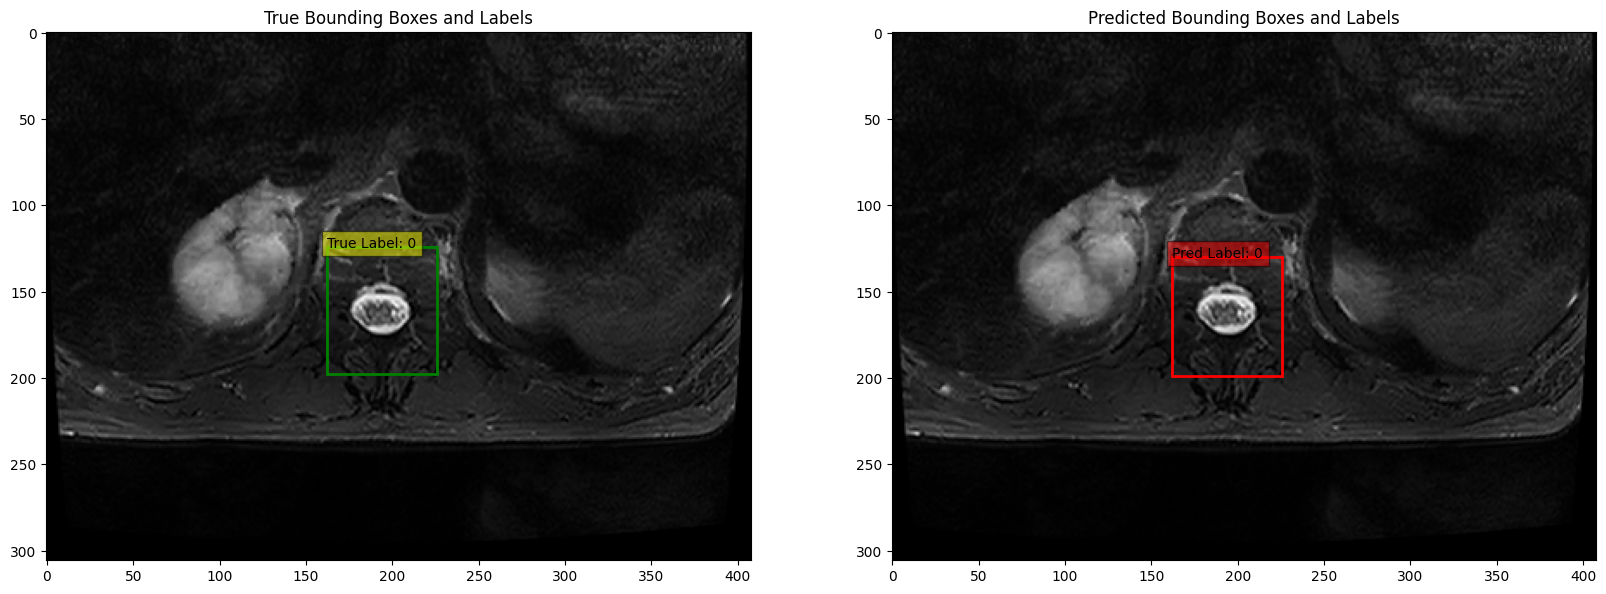

[{'boxes': tensor([[162.0930, 129.9787, 225.8772, 198.9416],
        [162.6844, 124.5156, 227.8683, 196.4807],
        [167.4697,  99.0808, 253.3673, 216.0789],
        [162.2651, 121.1219, 209.1321, 175.6555],
        [167.4697,  99.0808, 253.3673, 216.0789],
        [174.2974, 144.0740, 233.9862, 214.2151]], device='cuda:0'), 'scores': tensor([0.8451, 0.3897, 0.0894, 0.0675, 0.0599, 0.0512], device='cuda:0'), 'labels': tensor([0, 1, 0, 0, 1, 0], device='cuda:0')}]


In [ ]:
# individual prediction
import pydicom
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torchvision
from torchvision.transforms import functional as F

def load_dicom_image(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    img_array = ds.pixel_array
    img_array = (img_array / np.max(img_array) * 255).astype(np.uint8)
    return img_array

def load_labels(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    boxes = []
    labels = []
    for item in data['shapes']:
        box = item['points']
        label = item['label']
        boxes.append([box[0][0], box[0][1], box[1][0], box[1][1]])
        labels.append(int(label))
    return boxes, labels

model = torchvision.models.detection.retinanet_resnet50_fpn(pretrained=False, progress=True, num_classes=3)
weight = torch.load(r"D:\MED\SpM\SpM_pth\Retina\3_train_mIou_0.8730000257492065_valid_mIou_0.8809999823570251.pth")
model.load_state_dict(weight)
model = model.to('cuda')
model.eval()

ID = 12
dcm_path = dcm_valid[ID]
json_path = json_valid[ID]
img_array = load_dicom_image(dcm_path)
img_tensor = F.to_tensor(img_array).unsqueeze(0).to('cuda')

with torch.no_grad():
    prediction = model(img_tensor)

pred_boxes = prediction[0]['boxes'].cpu().numpy()
pred_scores = prediction[0]['scores'].cpu().numpy()
pred_labels = prediction[0]['labels'].cpu().numpy()  
threshold = 0.5  

pred_boxes = pred_boxes[pred_scores >= threshold]
pred_labels = pred_labels[pred_scores >= threshold]

true_boxes, true_labels = load_labels(json_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.imshow(img_array, cmap='gray')
for bbox, label in zip(true_boxes, true_labels):
    xmin, ymin, xmax, ymax = bbox
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='g', facecolor='none')
    ax1.add_patch(rect)
    ax1.text(xmin, ymin, f'True Label: {label}', bbox=dict(facecolor='yellow', alpha=0.5))
ax1.set_title('True Bounding Boxes and Labels')

ax2.imshow(img_array, cmap='gray')
for bbox, label in zip(pred_boxes, pred_labels):
    xmin, ymin, xmax, ymax = bbox
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='r', facecolor='none')
    ax2.add_patch(rect)
    ax2.text(xmin, ymin, f'Pred Label: {label}', bbox=dict(facecolor='red', alpha=0.5))
ax2.set_title('Predicted Bounding Boxes and Labels')

plt.show()
print(prediction)